In [29]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
customers = pd.read_csv("../data/customers.csv")
products  = pd.read_csv("../data/products.csv")
orders    = pd.read_csv("../data/orders.csv")
payments  = pd.read_csv("../data/payments.csv")


In [5]:
customers.head()

,customer_id,customer_name,city,email
0,1,Arun Kumar,Chennai,arun@gmail.com
1,2,Priya Sharma,Bangalore,priya@gmail.com
2,3,Rahul Verma,Delhi,rahul@gmail.com
3,4,Sneha Iyer,Coimbatore,sneha@gmail.com
4,5,Karthik Raj,Madurai,karthik@gmail.com


In [6]:
customers.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
orders.drop_duplicates(inplace=True)
payments.drop_duplicates(inplace=True)

orders['order_date'] = pd.to_datetime(orders['order_date'])


In [7]:
conn = sqlite3.connect("ecommerce.db")


In [8]:
conn.execute("""
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY,
    customer_name TEXT,
    city TEXT,
    email TEXT
);
""")


In [9]:
conn.execute("""
CREATE TABLE IF NOT EXISTS products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT,
    category TEXT,
    price REAL
);
""")


In [10]:
conn.execute("""
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY,
    order_date DATE,
    customer_id INTEGER,
    product_id INTEGER,
    quantity INTEGER,
    total_amount REAL
);
""")


In [11]:
conn.execute("""
CREATE TABLE IF NOT EXISTS payments (
    payment_id INTEGER PRIMARY KEY,
    order_id INTEGER,
    payment_mode TEXT,
    payment_status TEXT
);
""")

conn.commit()


In [12]:
customers.to_sql("customers", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)


7

In [13]:
query = """
SELECT SUM(total_amount) AS total_revenue
FROM orders;
"""
pd.read_sql(query, conn)


,total_revenue
0,99500


In [14]:
query = """
SELECT strftime('%Y-%m', order_date) AS month,
       SUM(total_amount) AS revenue
FROM orders
GROUP BY month
ORDER BY month;
"""
monthly_sales = pd.read_sql(query, conn)
monthly_sales


,month,revenue
0,2024-01,19000
1,2024-02,62000
2,2024-03,18500


In [15]:
query = """
SELECT p.product_name, SUM(o.total_amount) AS revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY revenue DESC
LIMIT 5;
"""
pd.read_sql(query, conn)


,product_name,revenue
0,Laptop,55000
1,Smartphone,30000
2,Office Chair,7000
3,Headphones,6000
4,Water Bottle,1500


In [16]:
query = """
SELECT payment_mode, COUNT(*) AS total_transactions
FROM payments
GROUP BY payment_mode;
"""
pd.read_sql(query, conn)


,payment_mode,total_transactions
0,Credit Card,2
1,Debit Card,1
2,Net Banking,1
3,UPI,3


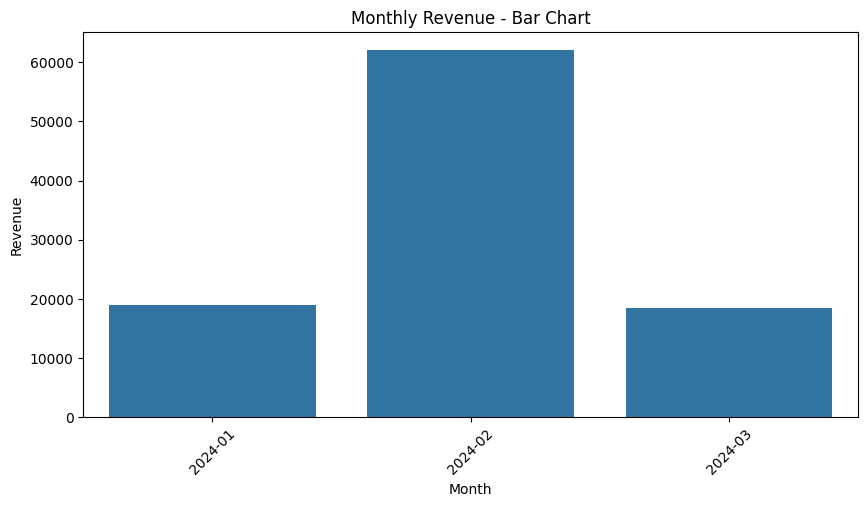

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(data=monthly_sales, x="month", y="revenue")
plt.xticks(rotation=45)
plt.title("Monthly Revenue - Bar Chart")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()



In [19]:
orders['customer_segment'] = orders['total_amount'].apply(
    lambda x: 'High Value' if x > 20000 else 'Medium' if x > 7000 else 'Low'
)

orders[['order_id', 'total_amount', 'customer_segment']]


,order_id,total_amount,customer_segment
0,1001,15000,Medium
1,1002,4000,Low
2,1003,55000,High Value
3,1004,7000,Low
4,1005,1500,Low
5,1006,2000,Low
6,1007,15000,Medium


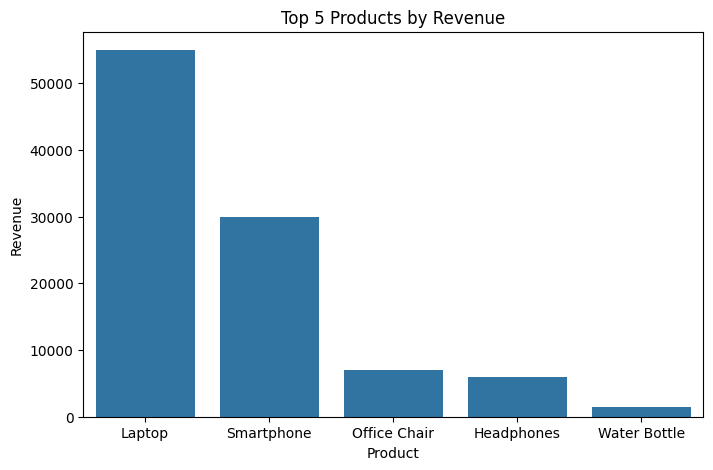

In [20]:
top_products = pd.read_sql("""
SELECT p.product_name, SUM(o.total_amount) AS revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.product_name
ORDER BY revenue DESC
LIMIT 5;
""", conn)

plt.figure(figsize=(8,5))
sns.barplot(data=top_products, x="product_name", y="revenue")
plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()


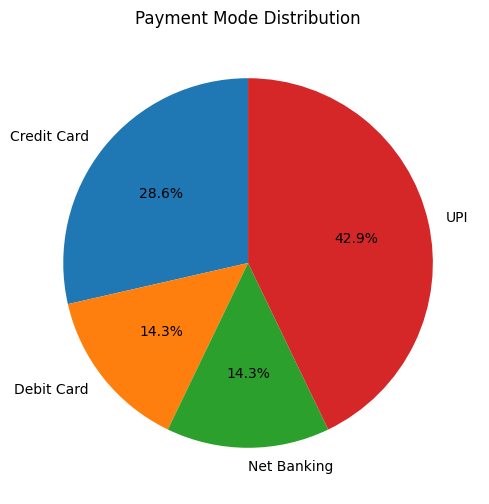

In [24]:
# Fetch payment mode data
payment_mode_df = pd.read_sql("""
SELECT payment_mode, COUNT(*) AS count
FROM payments
GROUP BY payment_mode;
""", conn)

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(
    payment_mode_df['count'],
    labels=payment_mode_df['payment_mode'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Payment Mode Distribution")
plt.show()
